In [1]:
import pandas as pd 

columns = ["A1","A2","A3","A4","A5","A6","A7","A8",
           "A9","A10","A11","A12","A13","A14","A15","A16"]

df = pd.read_csv(r"C:\works\learnings\statistics\credit+approval\crx.data", names= columns, na_values="?")

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [3]:
df["A16"].value_counts()

A16
-    383
+    307
Name: count, dtype: int64

In [4]:
df["A16"].value_counts()

A16
-    383
+    307
Name: count, dtype: int64

In [5]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64","int64"]).columns
print(categorical_cols,numerical_cols)

Index(['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16'], dtype='object') Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15'], dtype='object')


In [6]:
print(f"categorical_cols : {categorical_cols}")
print(f"numerical_cols : { numerical_cols}")

categorical_cols : Index(['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16'], dtype='object')
numerical_cols : Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15'], dtype='object')


In [7]:
df["A16"] = df["A16"].map({"+" : 1, "-" :0})

In [8]:
df["A16"]

0      1
1      1
2      1
3      1
4      1
      ..
685    0
686    0
687    0
688    0
689    0
Name: A16, Length: 690, dtype: int64

In [9]:
length = len(df)

In [10]:
def fidinf_missing_pct(col):
    missing = (df[col].isna().sum()/length)*100
    return f"{col} : {missing:.2f}%"

In [11]:
fidinf_missing_pct("A1")

'A1 : 1.74%'

In [12]:
missing_pct_each_col = [ fidinf_missing_pct(column)  for column in df.columns]
missing_pct_each_col = pd.DataFrame(missing_pct_each_col)
missing_pct_each_col

,0
0,A1 : 1.74%
1,A2 : 1.74%
2,A3 : 0.00%
3,A4 : 0.87%
4,A5 : 0.87%
5,A6 : 1.30%
6,A7 : 1.30%
7,A8 : 0.00%
8,A9 : 0.00%
9,A10 : 0.00%


In [13]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\RITHIK KUMAR\AppData\Local\Temp\ipykernel_8800\3631575163.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0],inplace=True)


In [14]:
import plotly.graph_objects as go 

In [15]:
for col in numerical_cols:
    fig = go.Figure(
        data=[
            go.Histogram(
                x=df[col],   
                nbinsx=50,       
                marker=dict(line=dict(width=1, color='black'))  
            )
        ]
    )

    fig.update_layout(
        title=f"Histogram of {col}",
        xaxis_title=col,
        yaxis_title="Count"
    )

    fig.show()

In [16]:
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness

A15    13.140655
A11     5.152520
A8      2.891330
A14     2.723993
A3      1.488813
A2      1.145892
dtype: float64

In [17]:
from sklearn.preprocessing import PowerTransformer 
pt = PowerTransformer(method="yeo-johnson")
high_skewness = skewness[skewness > 1].index
df[high_skewness] =  pt.fit_transform(df[high_skewness])

In [18]:
df[high_skewness].skew().sort_values(ascending=False)

A11    0.523861
A15    0.254594
A8     0.194239
A2     0.050724
A3     0.036904
A14   -0.345614
dtype: float64

In [19]:
for col in high_skewness:
    fig = go.Figure(
        data=[
            go.Histogram(
                x=df[col],   
                nbinsx=50,       
                marker=dict(line=dict(width=1, color='black'))  
            )
        ]
    )

    fig.update_layout(
        title=f"Histogram of {col}",
        xaxis_title=col,
        yaxis_title="Count"
    )

    fig.show()

array([[<Axes: title={'center': 'A15'}>, <Axes: title={'center': 'A11'}>],
       [<Axes: title={'center': 'A8'}>, <Axes: title={'center': 'A14'}>],
       [<Axes: title={'center': 'A3'}>, <Axes: title={'center': 'A2'}>]],
      dtype=object)

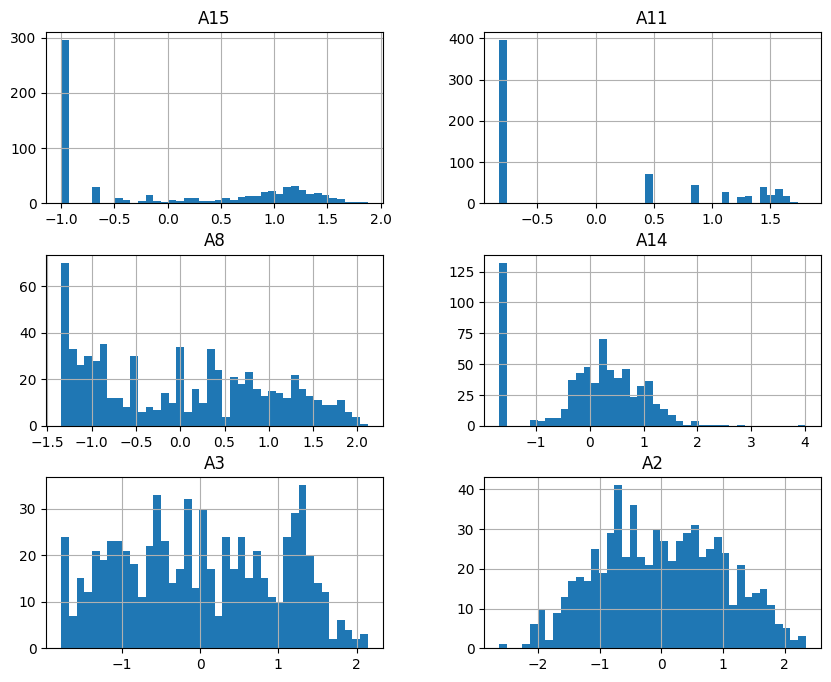

In [20]:
df[high_skewness].hist(bins=40, figsize=(10,8))

In [21]:
for col in high_skewness:
    df[col].fillna(df[col].mean(), inplace = True)
df[high_skewness].isna().sum()

C:\Users\RITHIK KUMAR\AppData\Local\Temp\ipykernel_8800\3038832874.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





A15    0
A11    0
A8     0
A14    0
A3     0
A2     0
dtype: int64

In [22]:
df.isna().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

In [23]:
numerical_cols

Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15'], dtype='object')

In [24]:
def find_IQR(df, cols):
    outlier_summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR 
        upper_bound = Q3 + 1.5 * IQR

        outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outlier)

    return outlier_summary

In [25]:
outlier_count = find_IQR(df, numerical_cols)
outlier_count

{'A2': 0, 'A3': 0, 'A8': 0, 'A11': 0, 'A14': 4, 'A15': 0}

**Histogram pot**

In [26]:
import plotly.express as px 

for col in numerical_cols:
    fig = px.histogram(df, x = col, marginal="box" ,nbins=30, title=f"Distribution plot for {col} (Histogram + Box)", opacity=0.7, width = 600)
    fig.show()

In [27]:
from scipy.stats import norm
import numpy as np 

In [28]:
for col in numerical_cols:
    x = df[col].dropna()
    x_sorted = np.sort(x)
    n = len(x_sorted)

    theoretical_q = norm.ppf(np.linspace(0.01,0.99, n))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=theoretical_q, y = x_sorted, mode="markers", name="Data"))
    fig.add_trace(go.Scatter(x=theoretical_q, y=theoretical_q,mode="lines", name="Ideal Line"))
    fig.update_layout(title=f"Q-Q Plot for {col}",xaxis_title="Theoretical Quantiles",yaxis_title="Sample Quantiles")
    fig.show()

Interpretation:

If points ≈ diagonal line → roughly normal.

S-shaped pattern → right or left skew.

Heavy tails → kurtosis (leptokurtic/platykurtic).

In [29]:
from scipy.stats import shapiro

for col in numerical_cols:
    stat, p = shapiro(df[col])
    print(f"{col}: W={stat:.3f}, p-value={p:.4f}")


A2: W=0.989, p-value=0.0000
A3: W=0.965, p-value=0.0000
A8: W=0.932, p-value=0.0000
A11: W=0.729, p-value=0.0000
A14: W=0.918, p-value=0.0000
A15: W=0.804, p-value=0.0000


In [30]:
cor_matrx = df[numerical_cols].corr()
cor_matrx

,A2,A3,A8,A11,A14,A15
A2,1.000000,0.136278,0.277317,0.117253,-0.109702,0.051752
A3,0.136278,1.000000,0.280010,0.204306,-0.275556,0.116073
A8,0.277317,0.280010,1.000000,0.318932,-0.082186,0.090692
A11,0.117253,0.204306,0.318932,1.000000,-0.137827,0.416697
A14,-0.109702,-0.275556,-0.082186,-0.137827,1.000000,-0.091929
A15,0.051752,0.116073,0.090692,0.416697,-0.091929,1.000000


In [31]:
fig = px.imshow(cor_matrx,text_auto=True, color_continuous_scale= 'RdBu_r', title="Corelation Heatmap Of numeric Features")
fig.update_layout(title_x = 0.5, width = 1000, height = 700)
fig.show()

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from statsmodels.tools.tools import add_constant

x = df[numerical_cols]
x_constant = add_constant(x)


vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["VIF"] = [ variance_inflation_factor(x_constant.values, i+1) for i in range(len(x.columns))]
vif_data

,features,VIF
0,A2,1.094632
1,A3,1.181516
2,A8,1.251822
3,A11,1.358539
4,A14,1.097841
5,A15,1.216975


In [33]:
print(vif_data)

  features       VIF
0       A2  1.094632
1       A3  1.181516
2       A8  1.251822
3      A11  1.358539
4      A14  1.097841
5      A15  1.216975


**Statistical takeaway**

*All VIF values are very close to 1, meaning each numeric feature is nearly independent of the others.*

*There’s no redundant information among numeric predictors.*

*This ensures your regression coefficients and t-tests will be stable and interpretable.*

*In plain terms: the dataset is statistically clean and model-ready.*

In [34]:
approved = df[df["A16"] == 1 ]
rejected = df[df["A16"] == 0 ]

In [35]:
from scipy.stats import ttest_ind
normal_vars = [ "A2","A3","A8","A14"]
for col in normal_vars:
    stat , p_value = ttest_ind(approved[col], rejected[col], equal_var=False)
    print(f"{col} , t-test = {stat:.2f}, p_value = {p_value:.2f}")

A2 , t-test = 4.19, p_value = 0.00
A3 , t-test = 5.05, p_value = 0.00
A8 , t-test = 11.02, p_value = 0.00
A14 , t-test = -4.09, p_value = 0.00


In [36]:
from scipy.stats import mannwhitneyu
non_normal_vars = ["A11", "A15"]

for  col in non_normal_vars:
    stat, p_value = mannwhitneyu(approved[col], rejected[col])
    print(f"{col}, t-test : {stat:.2f}, P_value : {p_value:.2f}")

A11, t-test : 90213.50, P_value : 0.00
A15, t-test : 77296.00, P_value : 0.00


**All p-values are < 0.05, which means that every numeric feature exhibits a statistically significant difference between the approved (1) and rejected (0) credit groups.**

In [37]:
categorical_cols

Index(['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16'], dtype='object')

In [38]:
from scipy.stats import chi2_contingency

categorical_cols = ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['A16'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append([col, round(chi2, 3), round(p, 5)])

chi_results = pd.DataFrame(results, columns=['Feature', 'Chi-square', 'p-value'])
chi_results


,Feature,Chi-square,p-value
0,A1,0.458,0.49853
1,A4,26.694,0.00000
2,A5,26.694,0.00000
3,A6,98.323,0.00000
4,A7,45.019,0.00000
5,A9,355.204,0.00000
6,A10,143.070,0.00000
7,A12,0.568,0.45095
8,A13,9.192,0.01009


In [39]:
print(chi_results)

  Feature  Chi-square  p-value
0      A1       0.458  0.49853
1      A4      26.694  0.00000
2      A5      26.694  0.00000
3      A6      98.323  0.00000
4      A7      45.019  0.00000
5      A9     355.204  0.00000
6     A10     143.070  0.00000
7     A12       0.568  0.45095
8     A13       9.192  0.01009


In [40]:
from sklearn.model_selection import train_test_split

X = df.drop('A16', axis=1)
y = df['A16']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

categorical_cols = ['A4','A5','A6','A7','A9','A10','A13']
numeric_cols = ['A2','A3','A8','A11','A14','A15']

# Encoder + model pipeline
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)


ValueError: could not convert string to float: 'b'

In [42]:
for col in numeric_cols:
    has_values = df[col].isin(["t", "b", "?", "f"]).any()
    if has_values:
        print(f"{col}: Found unusual values")
        print(df[df[col].isin(["t", "b", "?", "f"])][col].value_counts())